In [25]:
import pandas as pd
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import torch.nn as nn

In [2]:
# df_true is the big dataset (10mil samples)
#df_true = pd.read_csv('./data/midwest/midwest-big-train.csv')

# Try with a subset of specific types of restaurants
df = pd.read_csv('./data/midwest/hotdogs.csv')


In [35]:
# Skip this if not using df_true

def proportional_sample(df, col_name, sample_size):
    value_counts = df[col_name].value_counts(normalize=True)
    sampled_counts = (value_counts * sample_size).round().astype(int)

    sampled_dfs = []
    for value, count in sampled_counts.items():
        subset = df[df[col_name] == value].sample(n=min(count, len(df[df[col_name] == value])), replace=False) #sample without replacement, take the minimum of the count or the amount of that value in the df.
        sampled_dfs.append(subset)

    sampled_df = pd.concat(sampled_dfs)
    return sampled_df

## Take a proportional slice of the text to practice with
sample_size = 1000000
df = proportional_sample(df_true, 'rating', sample_size)

In [3]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def pnn(n):
    if n in {1,2}: return 0
    elif n in {3,4}: return 1
    else: return 2

def preprocess_text(text):
    # Maybe there's a better way to do this, but it gets hung up on reviews that are just integers 
    # I don't know why someone would leave such a review but there are a few
    text = str(text) 
    # Make lowercase and remove puncuation 
    text = text.lower()
    text = text.replace('translated by google', '')
    text = text.replace('\n', ' ')
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

def minus1(n):
    return n-1

# Turn ratings into +/-/neutral and do a bit of light processing to the text
# Careful to only run this once
df['pnn'] = df['rating'].apply(pnn) # 0 = negative, 1 = neutral/avg, 2 = positive
df['text'] = df['text'].apply(preprocess_text)
df['rating'] = df['rating'].apply(minus1)

In [4]:
df.head()

,rating,text,pnn
0,4,love this place,2
1,4,good food great ice cream plus garden supply ...,2
2,4,amazing chicago comfort food with awesome service,2
3,4,love this place hots dogs polish and shakes ar...,2
4,4,love their beef whot peppers mmm,2


Instantiate the bert model. Tried both base and large, no real difference in acc

In [5]:
from transformers import BertTokenizer, BertModel
from transformers import BertForSequenceClassification
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Base bert model should be sufficient. 
model_name = "bert-base-uncased" 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the tokenizer and model
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3).to(device)

#print(model)
print('Device: ', device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Device:  cuda


In [6]:
def tokenize_text(text):
    inputs = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
    return inputs

This chunk is for preliminary testing, it can be ignored

In [7]:
def predict_sentiment(text):
    inputs = tokenize_text(text)
    inputs = {key: val.to(device) for key, val in inputs.items()} #move the inputs to the correct device.
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
    return predicted_class

In [8]:
# Simple test cycle of the untrained model
review = 'The best chicken ever'
label = predict_sentiment(review)
meaning = ['negative', 'neutral/average', 'good']

print('Review: ', review)
print(f'Predicted rating: {label} {meaning[label]}')

Review:  The best chicken ever
Predicted rating: 1 neutral/average


Run this so that the training autogenerates a plot after finishing


In [9]:
import datetime
import matplotlib.pyplot as plt
import numpy as np

def plot_lists_with_colors(list1, list2, label1="List 1", label2="List 2", color1="blue", color2="red"):
    # Ensure lists have equal length (or adjust as needed)
    min_len = min(len(list1), len(list2))
    x_values = np.arange(min_len)

    # Create the plot
    plt.figure(figsize=(10, 6))  # Adjust figure size if needed

    # Plot List 1
    plt.plot(x_values, list1[:min_len], color=color1, label=label1, linestyle='none', marker='o')

    # Plot List 2
    plt.plot(x_values, list2[:min_len], color=color2, label=label2, linestyle='none', marker='o')

    current_time = datetime.datetime.now()
    
    # Add Labels and Title
    plt.xlabel("Epoch") 
    plt.ylabel("Accuracy (%)")
    plt.title(f"Bert - Midwest data ({current_time.strftime("%Y-%m-%d %H:%m")})")

    # Add Legend
    plt.legend()

    # Add Grid (Optional)
    plt.grid(True)

    
    file_name = f'./sshots/model-{current_time.strftime("%Y-%m-%d--%H%m")}.png'
    plt.savefig(file_name)
    
    # Show the Plot
    plt.show()

Training the BERT model begins here

In [12]:
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=25): #add max_length.
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length #store max length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        inputs = self.tokenizer(
            text,
            padding="max_length", #important
            truncation=True, #important
            max_length=self.max_length, #important
            return_tensors="pt")
        
        input_ids = inputs['input_ids'].flatten()
        attention_mask = inputs['attention_mask'].flatten()
        label_tensor = torch.tensor(label)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': label_tensor
        }

In [19]:
from sklearn.utils import class_weight

def calculate_class_weights(labels):
    """Calculates class weights for imbalanced datasets."""
    class_weights = class_weight.compute_class_weight(
        'balanced',
        classes=np.unique(labels),
        y=labels
    )
    return torch.tensor(class_weights, dtype=torch.float)


In [27]:
# Export the text and ratings to a list, this part is necessary otherwise pandas keeps the index
X = df['text'].values.tolist()
y = df['pnn'].values.tolist()

# The batch size seems to need to be pretty small, anything more than 32 crashed my 3070 with 8GB VRAM
# monitor RAM use in the terminal with "watch -n5 nvidia-smi"
# Other parameters for the training are set here as well
batch_size = 16
max_length = 25
learning_rate = .0001
weight_decay = .01

## FREEZE the base BERT parameters and only train the classification layer
for param in model.bert.parameters():
    param.requires_grad = False
    
# Remember to stratify based on the ratings
train_texts, test_texts, train_labels, test_labels = train_test_split(X, y, test_size=.2, stratify=y)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, max_length=max_length)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, max_length=max_length)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Adjust learning rate and weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Calculate class weights only after the split
class_weights = calculate_class_weights(train_labels)
criterion = nn.CrossEntropyLoss(weight=class_weights)

Epoch 1/3: 100%|█████████████████████████████████████████| 3753/3753 [00:56<00:00, 66.67it/s]


Train loss: 0.52727, acc 77.36% | Test acc: 77.74%


Epoch 2/3: 100%|█████████████████████████████████████████| 3753/3753 [00:58<00:00, 64.17it/s]


Train loss: 0.52747, acc 77.33% | Test acc: 77.76%


Epoch 3/3: 100%|█████████████████████████████████████████| 3753/3753 [00:58<00:00, 63.64it/s]


Train loss: 0.52731, acc 77.41% | Test acc: 77.69%


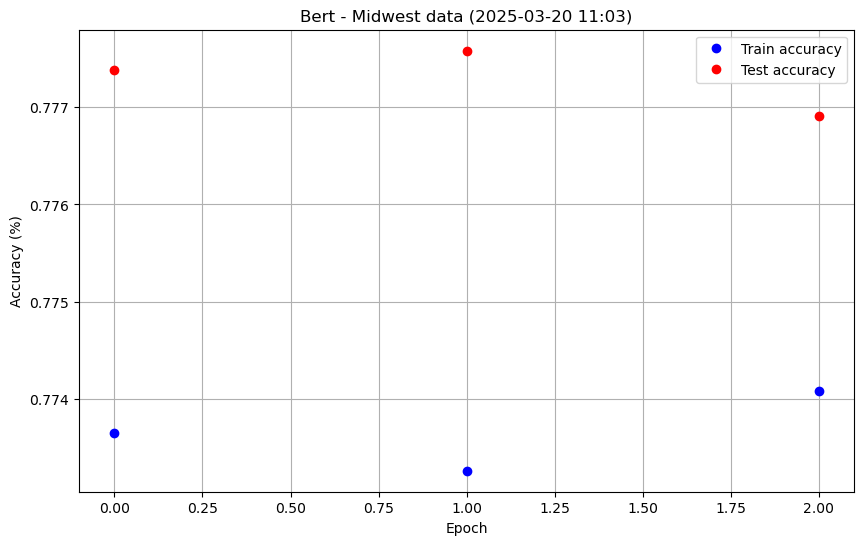

In [34]:
epochs = 3
accs = [[], []] #0 = Train, 1 = Test

for epoch in range(epochs):
    #Train cycle
    model.train()
    
    train_loss = 0
    all_predicted_labels, all_true_labels = [], []
    
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs}"):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

        ## used for calculating accuracy
        _, predicted_labels = torch.max(outputs.logits, dim=1)
        all_predicted_labels.extend(predicted_labels.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

        ## Training
        loss = outputs.loss
        train_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()

    acc = accuracy_score(all_true_labels, all_predicted_labels)
    accs[0].append(acc)
    tr_l = train_loss / len(train_dataloader)
    
    # Test cycle
    print('Testing...', end='\r')
    model.eval()
    
    test_loss = 0
    all_predicted_labels, all_true_labels = [], []
    
    
    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            
            _, predicted_labels = torch.max(outputs.logits, dim=1)
            all_predicted_labels.extend(predicted_labels.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())


    acc = accuracy_score(all_true_labels, all_predicted_labels)
    accs[1].append(acc)
    
    print(f'Train loss: {tr_l:.5f}, acc {100*accs[0][epoch]:.2f}% | Test acc: {100*accs[1][epoch]:.2f}%')

# Plot the accuracies on completion
plot_lists_with_colors(accs[0], accs[1], label1="Train accuracy", label2="Test accuracy")